In [1]:
# Import libraries
import torch
import numpy as np
import random
import copy
import gc
import sys
sys.path.append("..")
from models import *
import matplotlib.pyplot as plt
from diffusers import LMSDiscreteScheduler, DDIMScheduler, AutoencoderKL
from utils import *
import timeit
from tqdm.auto import tqdm
from evaluation import *
from ddim import *
from Cebra import cebra_model

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the autoencoder model which will be used to decode the latents into image space. 
vae = AutoencoderKL.from_pretrained("CompVis/stable-diffusion-v1-4", subfolder="vae")
# To the GPU we go!
vae = vae.to(device)


# The noise scheduler
noise_scheduler = LMSDiscreteScheduler(
    beta_start=0.00085, beta_end=0.012, beta_schedule="scaled_linear", num_train_timesteps=1000
)

In [2]:
# Load Data
M = 20

labels_raw = np.load('../data/raw_labels_{}.npy'.format(M))
Z_data = np.load('../data/ddim_latents_{}.npy'.format(M))
ca_labels = np.load('../data/norm_labels_{}.npy'.format(M))

labels = ca_labels[:,1]
num_frames = len(labels)

number_list = list(range(4800))
train_block_size = 41
test_block_size = 7
num_blocks = 100
train_blocks = [number_list[i * (train_block_size+test_block_size)  : (i + 1) * train_block_size + test_block_size*i] 
                for i in range(num_blocks)]
test_blocks = [number_list[(i + 1) * train_block_size + test_block_size*i : (i+1)*(train_block_size + test_block_size)]
               for i in range(num_blocks)]  
idx_train = []
idx_test = []
for j in range(num_blocks):
    idx_train = idx_train + train_blocks[j]
    idx_test = idx_test + test_blocks[j]

print("Train:", len(idx_train), "Test:", len(idx_test))

cebra_model.fit(Z_data[idx_train],ca_labels[idx_train])
C_train = cebra_model.transform(Z_data[idx_train])
C_test = cebra_model.transform(Z_data[idx_test])

Train: 4100 Test: 700


pos:  1.9425 neg: -2.4317 total: -0.4892


In [3]:
# kNN 
import cebra
knn_model = cebra.KNNDecoder(metric="euclidean")
knn_model.fit(C_train, Z_data[idx_train])
knn_pred = knn_model.predict(C_test)

In [4]:
# PCA
d = 3
from sklearn.decomposition import PCA
pca_model = PCA(n_components = d)

pca_latents = pca_model.fit_transform(Z_data)

pca_pred = pca_model.inverse_transform(pca_latents[idx_test])

In [5]:
# Beta VAE
from beta_VAE import *

data_train = torch.tensor(Z_data[idx_train], dtype=torch.float32)  # shape (N, 4096)
data_test = torch.tensor(Z_data[idx_test], dtype=torch.float32) 

latent_dim = d
input_dim = Z_data.shape[1]
epochs = 100
batch_size = 64
lr = 1e-4
max_beta = 4.0

train_loader = DataLoader(TensorDataset(data_train), batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(TensorDataset(data_test), batch_size=batch_size, shuffle=False)

# Training loop with KL annealing
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
bvae_model = BetaVAE(input_dim=input_dim, latent_dim=latent_dim).to(device)
optimizer = torch.optim.Adam(bvae_model.parameters(), lr=lr)

for epoch in range(epochs):
    # ---------- TRAIN ----------
    bvae_model.train()
    bvae_model.beta = anneal_beta(epoch, warmup=20, max_beta=max_beta)

    train_loss_sum = 0.0
    train_recon_sum = 0.0
    train_kl_sum = 0.0
    train_count = 0

    for (x,) in train_loader:
        x = x.to(device)
        x_recon, mu, logvar = bvae_model(x)
        loss, recon, kl = bvae_model.loss_function(x, x_recon, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        bsz = x.size(0)
        train_loss_sum  += loss.item()  * bsz
        train_recon_sum += recon.item() * bsz
        train_kl_sum    += kl.item()    * bsz
        train_count     += bsz

    train_loss = train_loss_sum / train_count
    train_recon = train_recon_sum / train_count
    train_kl = train_kl_sum / train_count

    # ---------- TEST ----------
    bvae_model.eval()
    test_loss_sum = 0.0
    test_recon_sum = 0.0
    test_kl_sum = 0.0
    test_count = 0

    with torch.no_grad():
        for (x,) in test_loader:
            x = x.to(device)
            x_recon, mu, logvar = bvae_model(x)
            loss, recon, kl = bvae_model.loss_function(x, x_recon, mu, logvar)

            bsz = x.size(0)
            test_loss_sum  += loss.item()  * bsz
            test_recon_sum += recon.item() * bsz
            test_kl_sum    += kl.item()    * bsz
            test_count     += bsz

    test_loss = test_loss_sum / test_count
    test_recon = test_recon_sum / test_count
    test_kl = test_kl_sum / test_count

    print(f"Epoch {epoch+1:03d} | β={bvae_model.beta:.2f} | "
          f"Train: Loss={train_loss:.4f} Recon={train_recon:.4f} KL={train_kl:.4f} || "
          f"Test: Loss={test_loss:.4f} Recon={test_recon:.4f} KL={test_kl:.4f}")

Epoch 001 | β=0.00 | Train: Loss=160.9192 Recon=160.9192 KL=5.3181 || Test: Loss=149.2346 Recon=149.2346 KL=9.4693
Epoch 002 | β=0.20 | Train: Loss=148.8685 Recon=147.6241 KL=6.2215 || Test: Loss=147.3470 Recon=146.2319 KL=5.5754
Epoch 003 | β=0.40 | Train: Loss=147.4326 Recon=145.5806 KL=4.6299 || Test: Loss=146.8407 Recon=145.0825 KL=4.3955
Epoch 004 | β=0.60 | Train: Loss=147.1168 Recon=144.8215 KL=3.8255 || Test: Loss=146.7531 Recon=144.5390 KL=3.6901
Epoch 005 | β=0.80 | Train: Loss=146.8403 Recon=144.2277 KL=3.2658 || Test: Loss=146.6236 Recon=144.0915 KL=3.1652
Epoch 006 | β=1.00 | Train: Loss=146.7954 Recon=143.7682 KL=3.0272 || Test: Loss=146.6597 Recon=143.8572 KL=2.8025
Epoch 007 | β=1.20 | Train: Loss=146.8968 Recon=143.5394 KL=2.7978 || Test: Loss=147.0183 Recon=143.7714 KL=2.7058
Epoch 008 | β=1.40 | Train: Loss=147.0829 Recon=143.5012 KL=2.5584 || Test: Loss=147.2130 Recon=143.6350 KL=2.5557
Epoch 009 | β=1.60 | Train: Loss=147.4326 Recon=143.5731 KL=2.4121 || Test: Loss

In [6]:
bvae_model.eval()
with torch.no_grad():
    bvae_latents = data_test.to(device)
    x_recon, mu, logvar = bvae_model(bvae_latents)
    bvae_pred = x_recon.cpu().numpy()

In [7]:
niters = 50000
save_models_folder = '../output/saved_models'

Filename_LDM = save_models_folder + '/CcLDM_checkpoint_intrain/CcLDM_checkpoint_niters_{}.pth'.format(niters)
print("Loading pre-trained continuous conditional latent diffusion model >>>")
checkpoint = torch.load(Filename_LDM, map_location=device, weights_only=True)
netLDM = cont_cond_unet_diffusion_model().to(device)
netLDM = nn.DataParallel(netLDM)

# Adjust checkpoint keys if necessary
checkpoint_state_dict = checkpoint['netLDM_state_dict']
adjusted_state_dict = {}

for key, value in checkpoint_state_dict.items():
    # Replace naming inconsistencies
    new_key = key.replace("query", "to_q").replace("key", "to_k").replace("value", "to_v").replace("proj_attn", "to_out.0")
    adjusted_state_dict[new_key] = value

# Load the adjusted state dict
netLDM.load_state_dict(adjusted_state_dict, strict=True)

Loading pre-trained continuous conditional latent diffusion model >>>


<All keys matched successfully>

In [8]:
pca_tensor = torch.tensor(pca_pred.reshape(len(idx_test),4, 32, 32)).type(torch.float).to(device)
bvae_tensor = torch.tensor(bvae_pred.reshape(len(idx_test),4, 32, 32)).type(torch.float).to(device)
knn_tensor = torch.tensor(knn_pred.reshape(len(idx_test),4, 32, 32)).type(torch.float).to(device)
test_labels = torch.tensor(ca_labels[idx_test]).type(torch.float).to(device)

  0%|          | 0/999 [00:00<?, ?it/s]

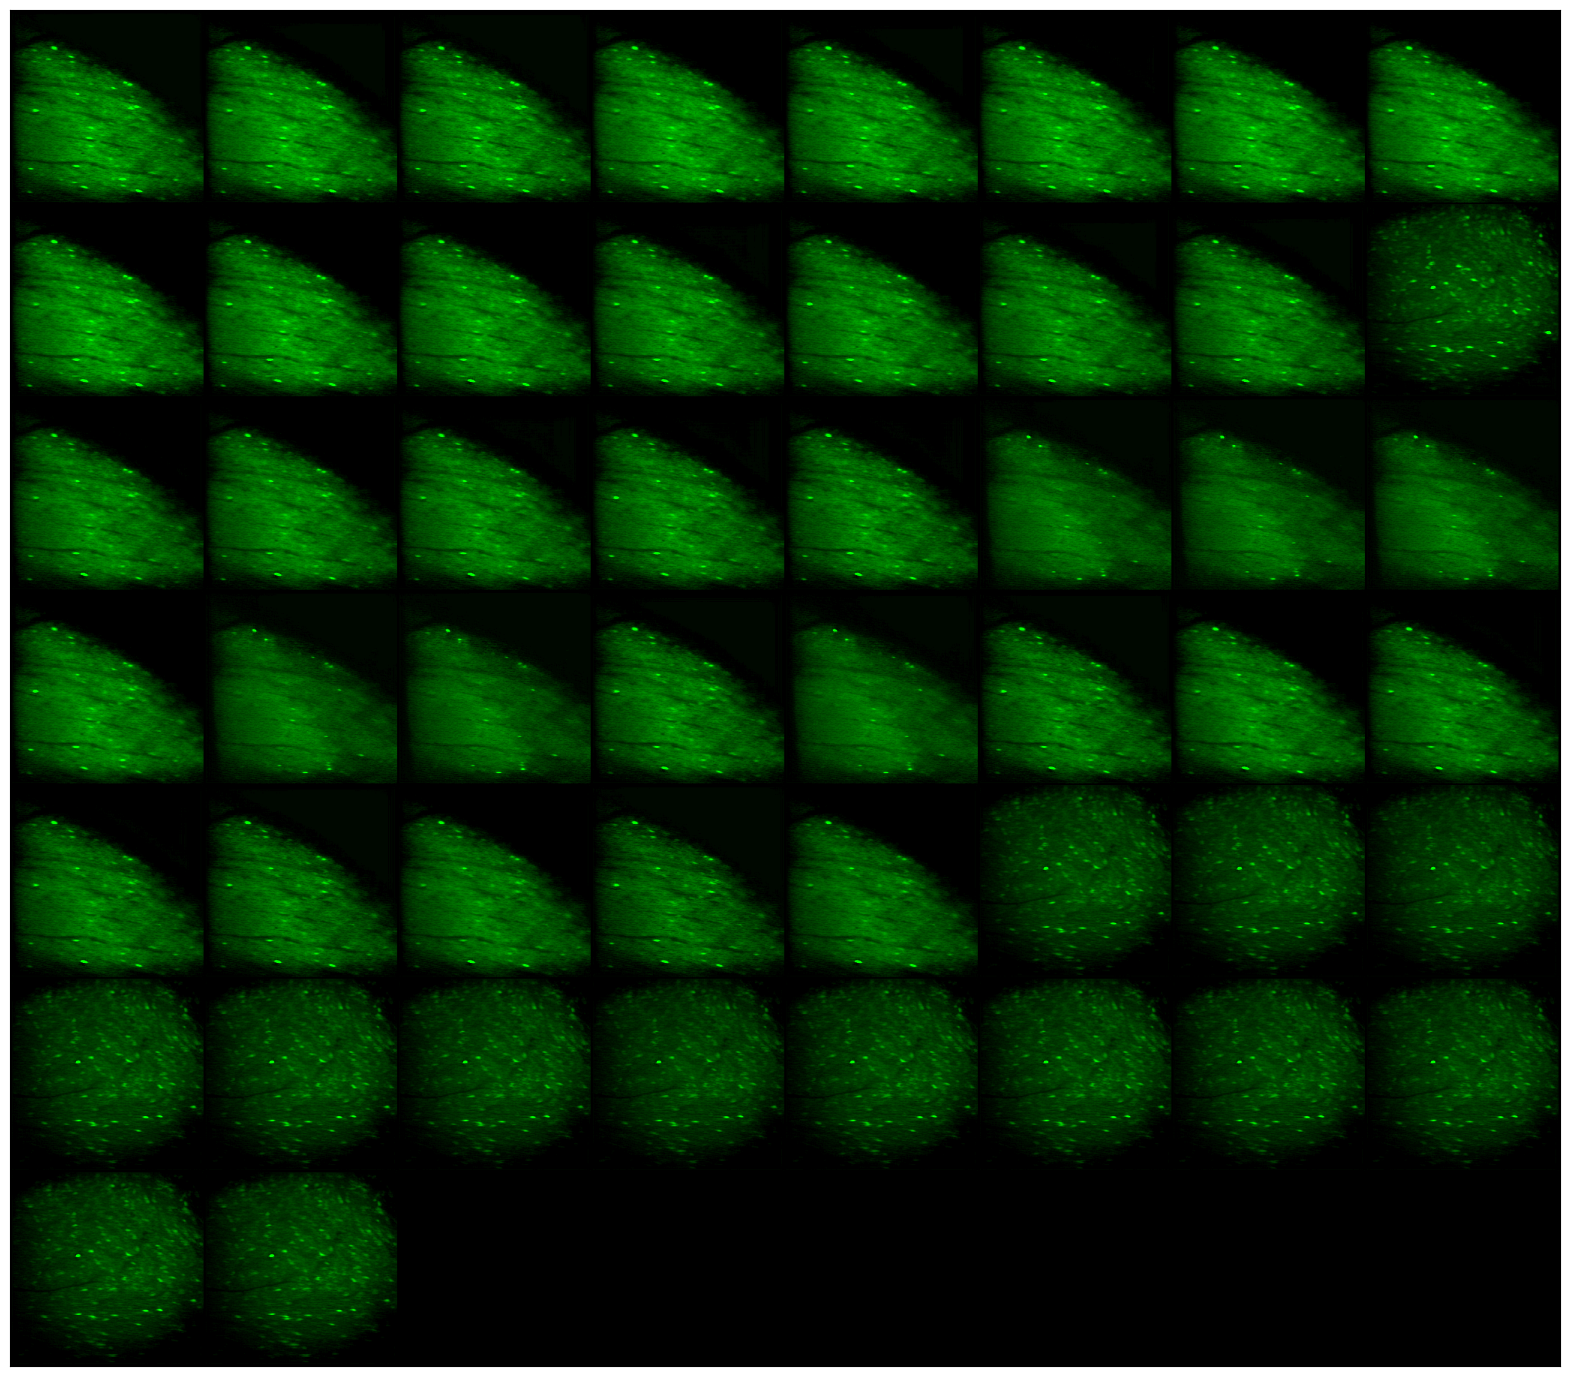

In [9]:
inf_steps = 1000
i = list(range(0,len(idx_test),14))
pca_sample = sample(start_latents=pca_tensor[i], num_inference_steps=inf_steps, 
                           labels=test_labels[i], noise_scheduler=noise_scheduler, netLDM=netLDM, 
                           start_step=0, device=device)
pca_sample = (1 / 0.18215) * pca_sample[-1]
with torch.no_grad():
    x_pca = vae.decode(pca_sample).sample 
show_images(x_pca)

  0%|          | 0/999 [00:00<?, ?it/s]

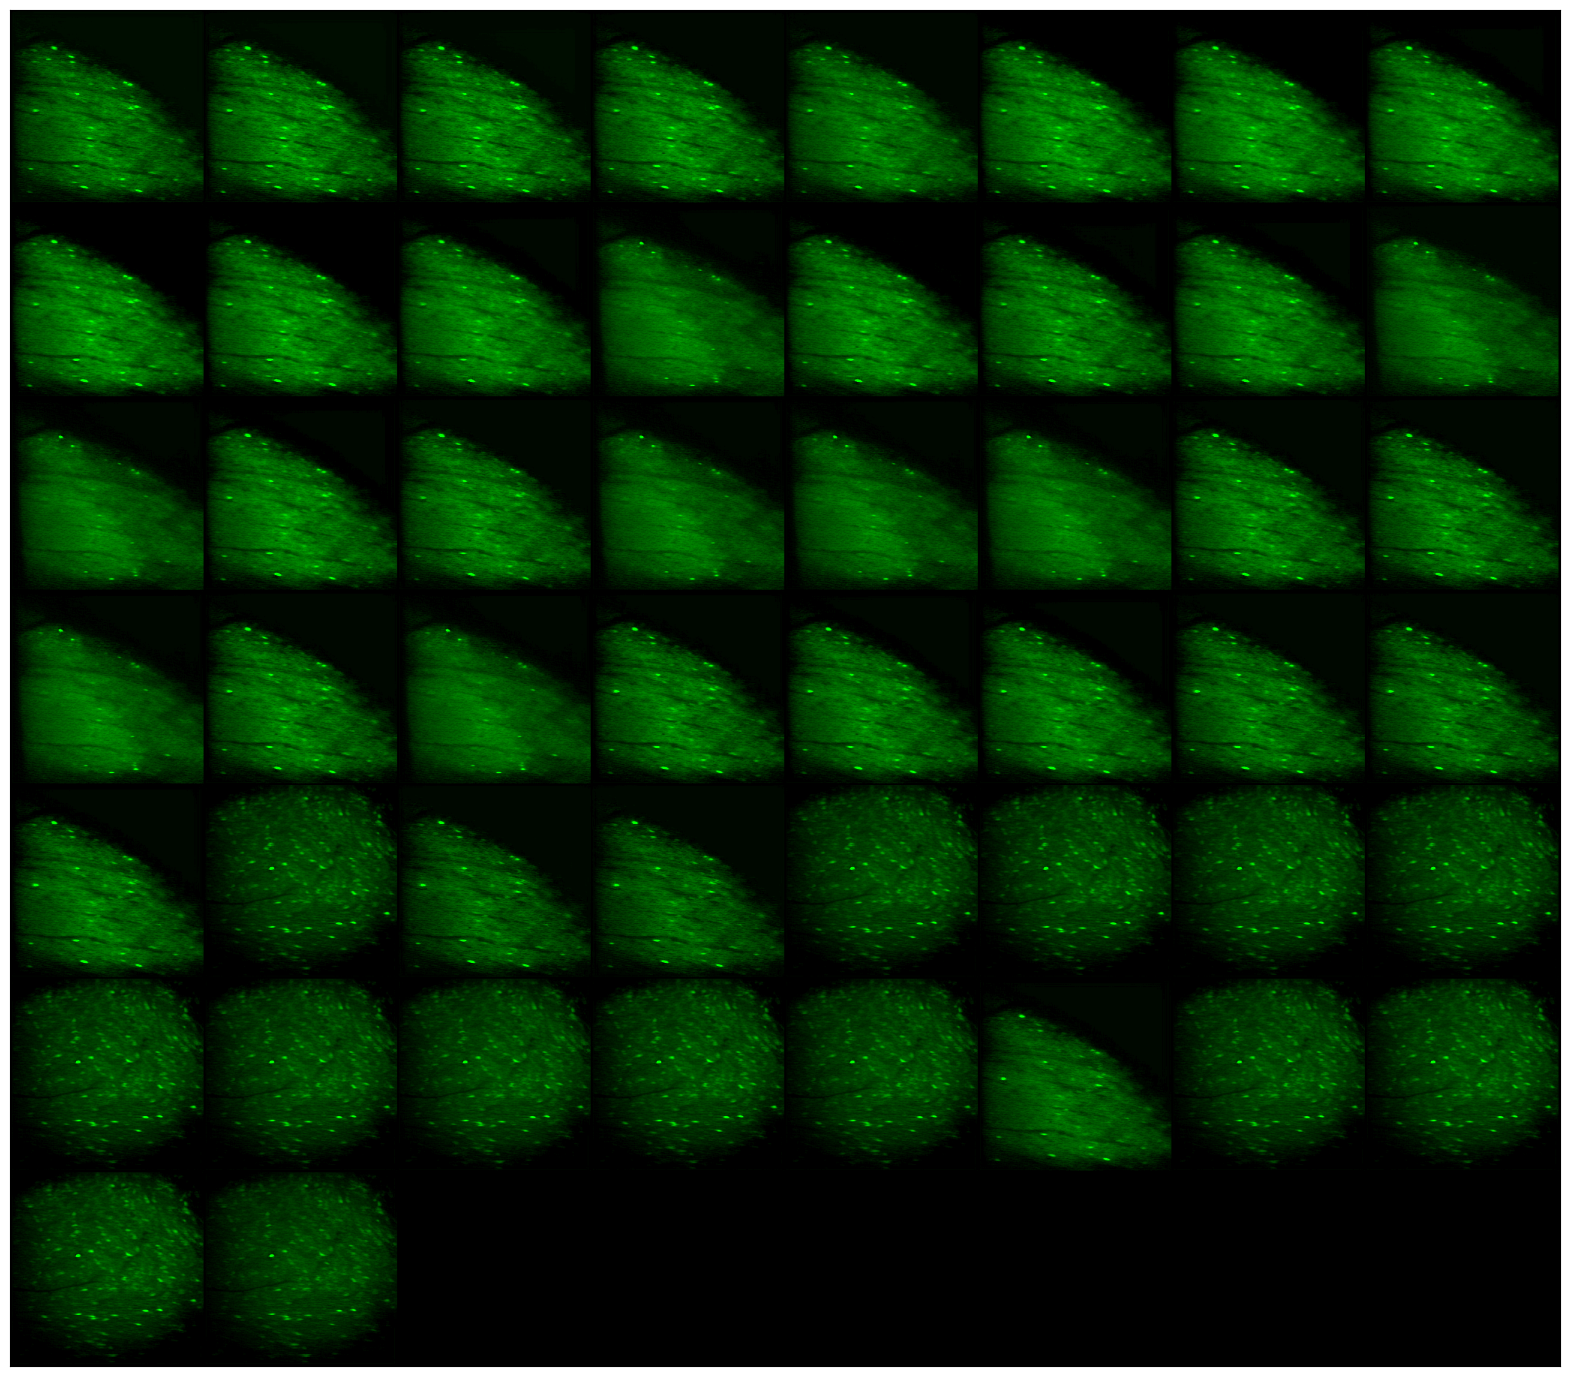

In [10]:
bvae_sample = sample(start_latents=bvae_tensor[i], num_inference_steps=inf_steps, 
                           labels=test_labels[i], noise_scheduler=noise_scheduler, netLDM=netLDM, 
                           start_step=0, device=device)
bvae_sample = (1 / 0.18215) * bvae_sample[-1]
with torch.no_grad():
    x_bvae = vae.decode(bvae_sample).sample 
show_images(x_bvae)

  0%|          | 0/999 [00:00<?, ?it/s]

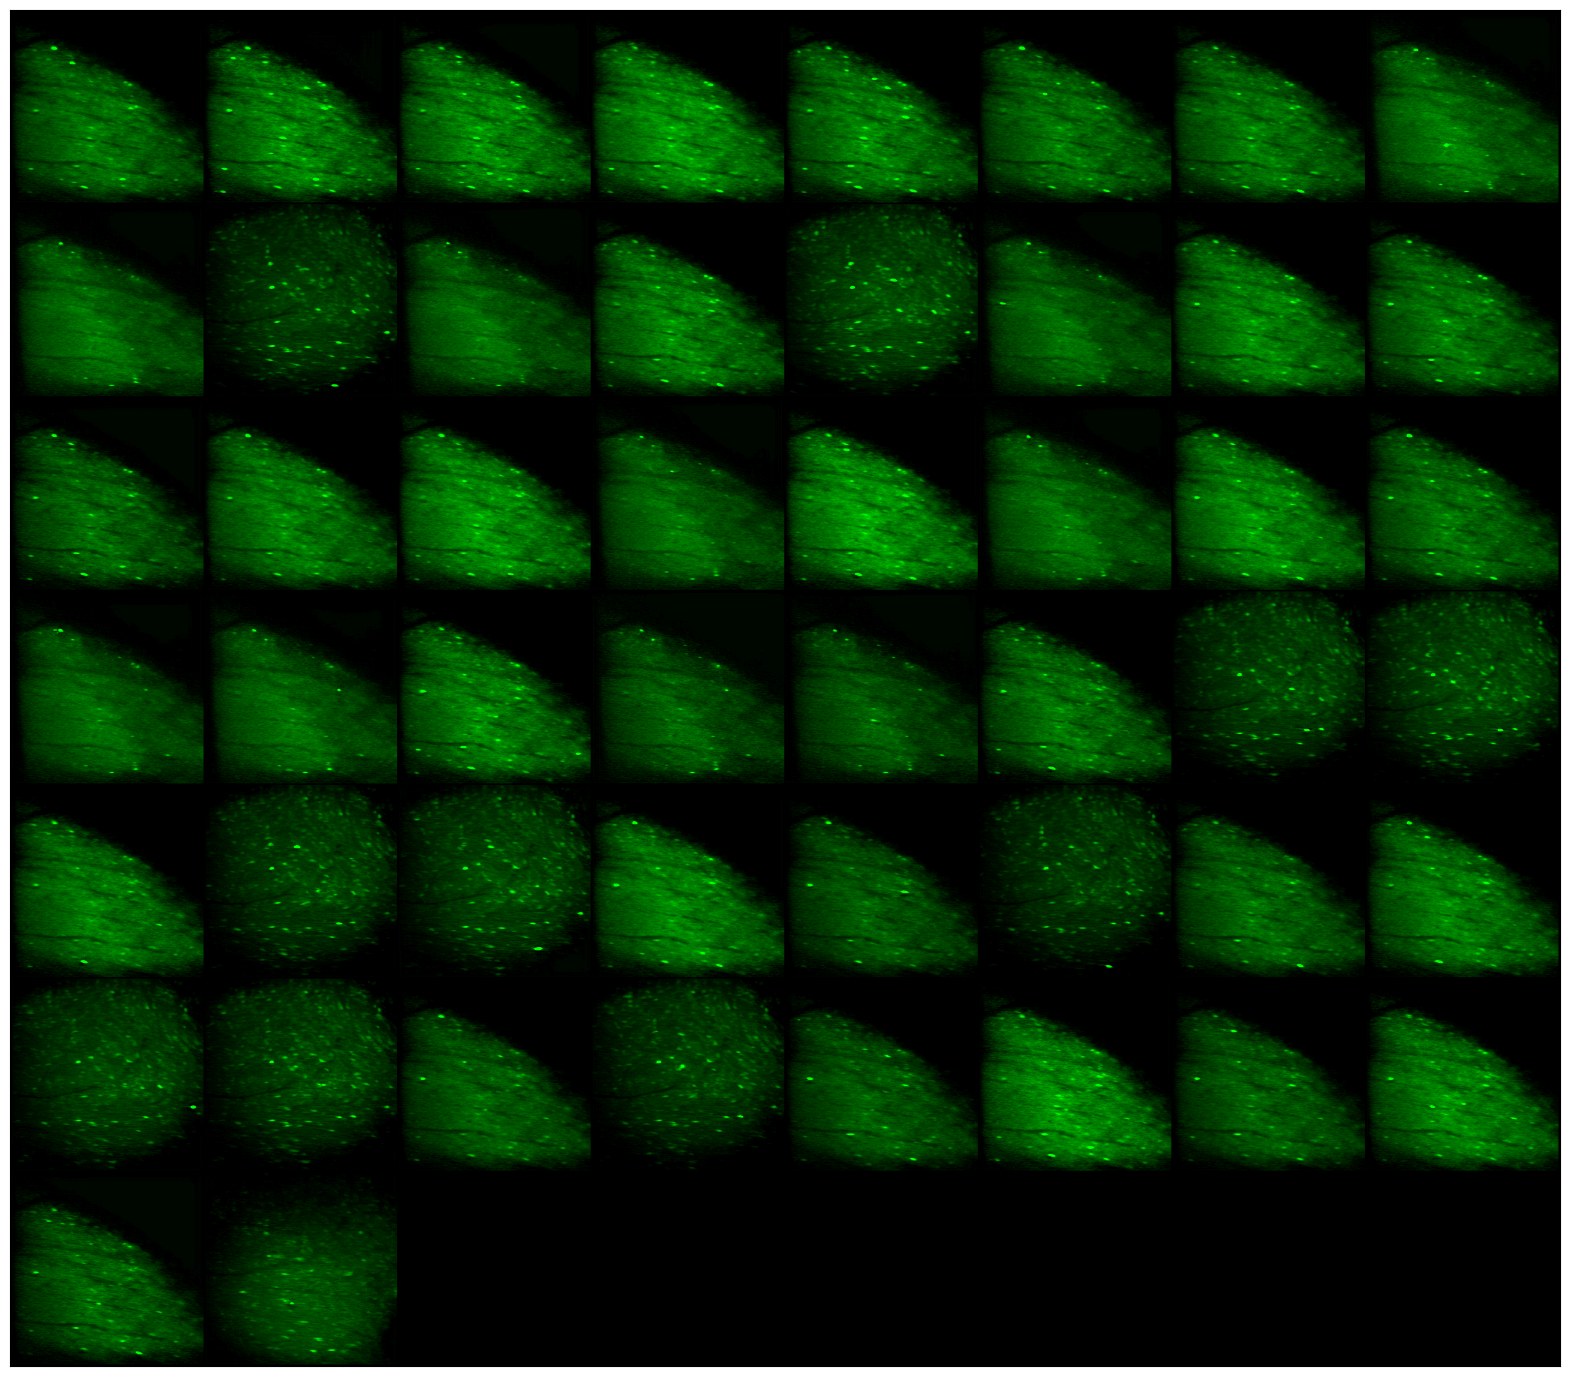

In [11]:
conda_sample = sample(start_latents=knn_tensor[i], num_inference_steps=inf_steps, 
                           labels=test_labels[i], noise_scheduler=noise_scheduler, netLDM=netLDM, 
                           start_step=0, device=device)
conda_sample = (1 / 0.18215) * conda_sample[-1]
with torch.no_grad():
    x_conda = vae.decode(conda_sample).sample 
show_images(x_conda)

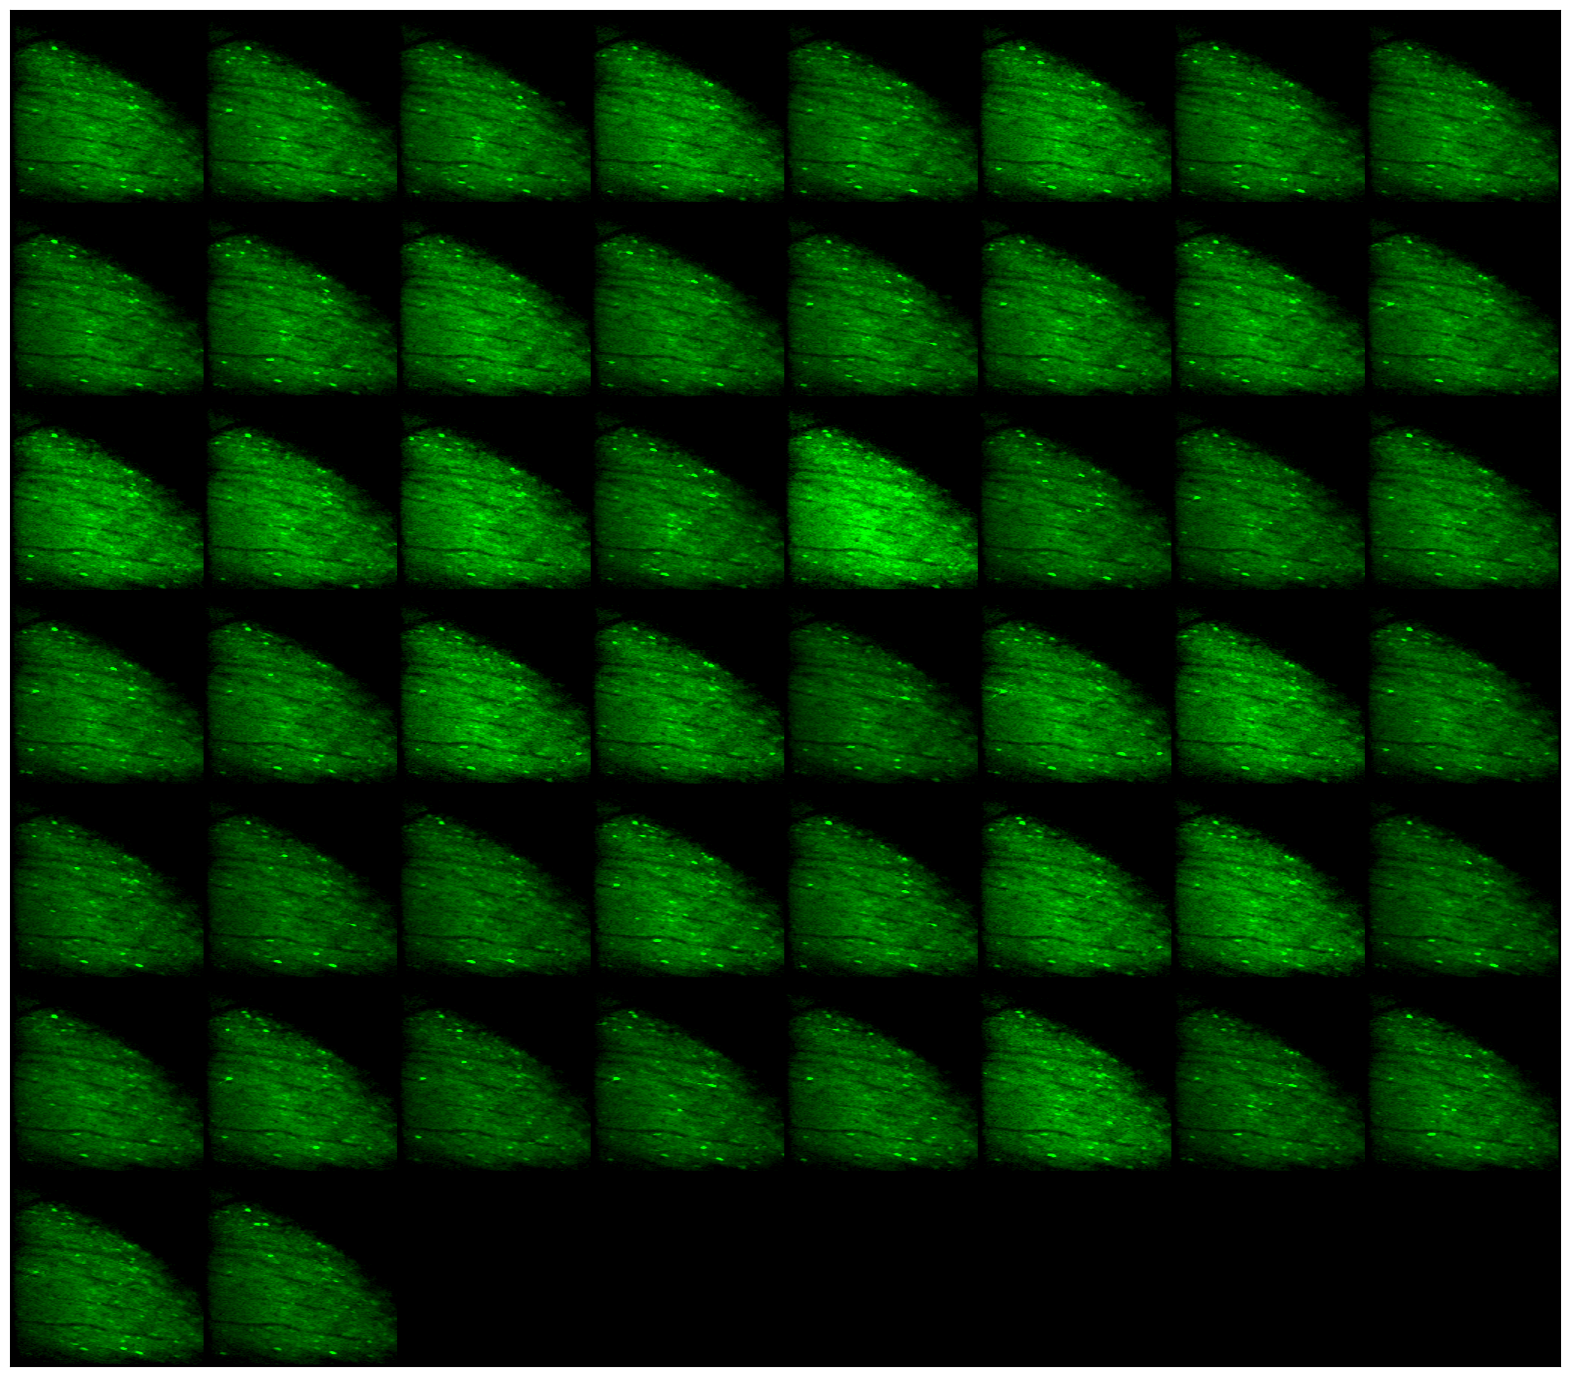

In [12]:
X_data = np.load('../data/X_data_{}.npy'.format(M))[idx_test]
real_images = torch.tensor(X_data[i]).type(torch.float) 
show_images(real_images)